# 1. Images Generation with GANs

This project implements a Generative Adversarial Network (GAN) to generate fashion images using the Fashion MNIST dataset. The notebook contains a complete implementation of both generator and discriminator models, training loop, and visualization of generated images.

## 1.1. Project Overview

The project demonstrates:
- Loading and preprocessing the Fashion MNIST dataset
- Building a DCGAN (Deep Convolutional Generative Adversarial Network) architecture
- Training the GAN with proper loss functions and optimizers
- Generating and visualizing synthetic fashion images
- Saving model checkpoints during training


## 1.2. Loading FMNIST

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from IPython.display import clear_output
from tensorflow.keras.models import load_model
import time
import numpy as np

In [ ]:
# Load the Fashion MNIST dataset
(train_images, train_labels), _ = tf.keras.datasets.fashion_mnist.load_data()

# Normalize the images to the range [-1, 1]
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1, 1]

# Define batch size and prepare the dataset for training
batch_size = 256

# Create the training dataset
train_ds = tf.data.Dataset.from_tensor_slices(train_images).shuffle(60000).batch(batch_size)

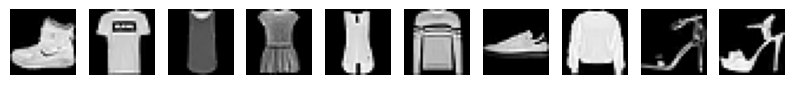

In [31]:
# Display some sample images
num_images_to_show = 10
plt.figure(figsize=(10, 10))
for i in range(num_images_to_show):
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

## 1.3. Structuring a Generator

In [ ]:
# Build the generator model
def build_generator():
    model = Sequential()

    model.add(layers.Input(shape=(100,)))
    model.add(layers.Dense(7*7*256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

## 1.4. Generating an Image

In [33]:
# Creation of the generator
generator = build_generator()

In [34]:
# Generate Noise Vector
noise_dimension = 100
noise = tf.random.normal([1, noise_dimension])

In [35]:
# Generate image from the noise vector
generated_image = generator(noise, training=False)

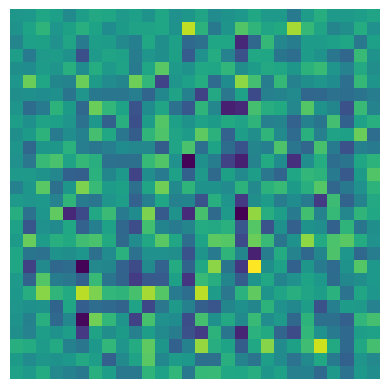

In [36]:
# View the generated image
plt.imshow((generated_image[0] * 127.5 + 127.5).numpy())
plt.axis('off')
plt.show()

# 2. Implementing a Discriminator

## 2.1. Creating the Discriminator Function

In [37]:
from tensorflow.keras.models import load_model
import os

In [ ]:
# Create the discriminator
def build_discriminator():
    model = Sequential()

    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Correct the Flatten dimension to match the Dense layer
    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [ ]:
# Create the discriminator
discriminator = build_discriminator()
decision = discriminator(generated_image)
print(decision)

tf.Tensor([[-0.00034464]], shape=(1, 1), dtype=float32)


## 2.2. Defining the Loss Functions

In [ ]:
# Define the loss function
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [ ]:
# Discriminator loss function
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [ ]:
# Generator loss function
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [ ]:
# Create Optmizer
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
# Create a checkpoint
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
    )

## 2.3. Defining a Training Loop

In [ ]:
# Training loop
epochs = 50
noise_dimension = 100
num_examples_training = 16

# Noise vector to generate images
seed = tf.random.normal([num_examples_training, noise_dimension])

In [ ]:
# Function to generate and save images
@tf.function
def training_step(images):
    noise = tf.random.normal([batch_size, noise_dimension])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [ ]:
# Function to generate and save images
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            training_step(image_batch)

        # Generate images to create a GIF
        clear_output(wait=True)
        generate_save_images(generator, epoch + 1, seed)

        # Save the model every 15 epochs
        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(f'Time for epoch {epoch + 1} is {time.time() - start} s')

    # Generate after the final epoch
    clear_output(wait=True)
    generate_save_images(generator, epoch + 1, seed)

In [ ]:
# Function to generate and save images
def generate_save_images(model, epoch, input):
  # Note that training is set to False.
  # This ensures all layers run in inference mode (batchnorm).

  prediction = model(input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(prediction.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(prediction[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

## 2.4. Applying the Training

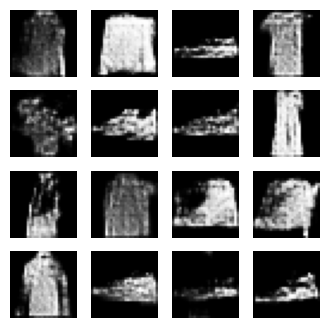

In [ ]:
# Start the training
train(train_ds, epochs)

In [ ]:
# Restore the latest checkpoint
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

In [ ]:
# Save the generator model
generator.save('model_generator.keras')

In [ ]:
# Load the generator model
loaded_generator = load_model('model_generator.keras')

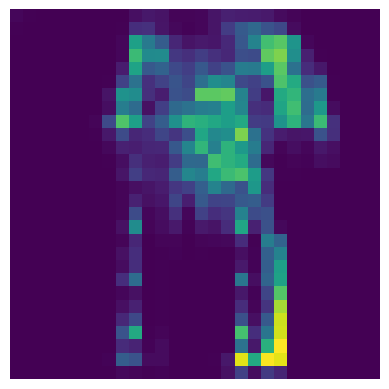

In [ ]:
# Verify the loaded model by generating an image
# Generate a new noise vector
new_noise = tf.random.normal([1, noise_dimension])

# Generate a new image using the loaded model
new_generated_image = loaded_generator(new_noise, training=False)

# Display the newly generated image
plt.imshow((new_generated_image[0] * 127.5 + 127.5).numpy().astype(np.uint8))
plt.axis('off')
plt.show()

# 3. Building a Diffuser

## 3.1. Adding Noise

In [56]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tqdm.auto import trange, tqdm

/home/anderjcruz/Deep-Learning/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Loading the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalizing images to the range [-1, 1]
X_train = (X_train / 127.5) - 1.0

# Adding an extra channel for 28x28 images
X_train = np.expand_dims(X_train, axis=-1)

In [ ]:
# Define constants
IMG_SIZE = 28      # Input image size, Fashion MNIST images are 28x28
BATCH_SIZE = 128   # Batch size for training
timesteps = 16     # Number of steps for a noisy image to become clear
time_bar = 1 - np.linspace(0, 1.0, timesteps + 1)  # linspace for timesteps

In [ ]:
# Function to convert image to float32 and normalize to [0, 1]
def cvtImg(img):
    img = img - img.min()
    img = (img / img.max())
    return img.astype(np.float32)

In [ ]:
# Function to display generated examples
def show_examples(x):
    num_images = x.shape[0]
    plt.figure(figsize=(10, 10))
    for i in range(min(25, num_images)): # Show up to 25 images
        plt.subplot(5, 5, i+1)
        img = cvtImg(x[i])
        plt.imshow(img.squeeze(), cmap='gray')  # Display as grayscale image
        plt.axis('off')

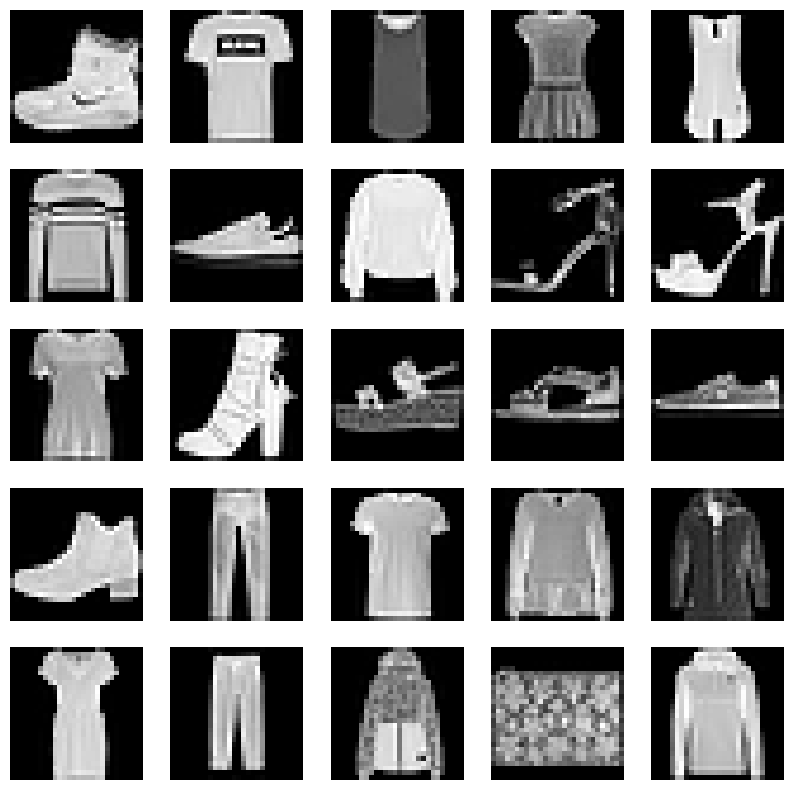

In [ ]:
# Display some training images
show_examples(X_train)

In [ ]:
# Function to add noise to an image based on time step t
def forward_noise(x, t):
    a = time_bar[t]      # Image at time t
    b = time_bar[t + 1]  # Image at time t + 1

    ruido = np.random.normal(size=x.shape)  # Generate noise mask
    a = a.reshape((-1, 1, 1, 1))
    b = b.reshape((-1, 1, 1, 1))
    img_a = x * (1 - a) + ruido * a
    img_b = x * (1 - b) + ruido * b
    return img_a, img_b

In [ ]:
# Function to generate random time steps
def generate_ts(num):
    return np.random.randint(0, timesteps, size=num)

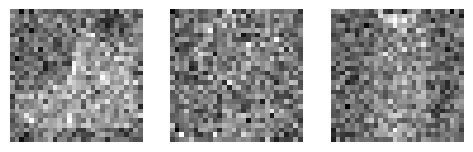

In [64]:
# Generate training examples
t = generate_ts(3)  # Generate timesteps for 3 examples
a, b = forward_noise(X_train[:3], t)
show_examples(a)

## 3.2. Implementing a U-Net

In [ ]:
# Define a block for the model
def block(x):
    x = layers.Conv2D(128, kernel_size=3, padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

In [ ]:
# Build the model
def make_model():
    # Input adjustment for Fashion MNIST
    x = x_input = layers.Input(shape=(28, 28, 1), name='x_input')

    x_ts = x_ts_input = layers.Input(shape=(1,), name='x_ts_input')
    x_ts = layers.Dense(192)(x_ts)
    x_ts = layers.LayerNormalization()(x_ts)
    x_ts = layers.Activation('relu')(x_ts)

    # ----- Convolutional Blocks -----
    x = x28 = block(x)  
    x = layers.MaxPool2D(2, padding='same')(x)  

    x = x14 = block(x)  
    x = layers.MaxPool2D(2, padding='same')(x)  

    x = x7 = block(x)  
    x = layers.MaxPool2D(2, padding='same')(x)  

    x = x4 = block(x)  

    # ----- MLP -----
    x = layers.Flatten()(x)
    x = layers.Concatenate()([x, x_ts])
    x = layers.Dense(128)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Dense(4 * 4 * 32)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Reshape((4, 4, 32))(x)

    # ----- Upsampling -----
    x = layers.Concatenate()([x, x4])
    x = block(x)
    x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(x)  

    # ----- Adjust to 7x7 -----
    x = layers.Cropping2D(((0, 1), (0, 1)))(x)  

    x = layers.Concatenate()([x, x7])
    x = block(x)
    x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(x)  

    x = layers.Concatenate()([x, x14])
    x = block(x)
    x = layers.Conv2DTranspose(128, kernel_size=3, strides=2, padding='same')(x)  

    x = layers.Concatenate()([x, x28])
    x = block(x)

    # ----- Output -----
    x = layers.Conv2D(1, kernel_size=1, padding='same')(x)
    model = tf.keras.models.Model([x_input, x_ts_input], x)
    
    return model

In [ ]:
# Create the model
model = make_model()

In [ ]:
# Compile the model
model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(), 
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0008)
    )

## 3.3. Creating Prediction Functions

In [ ]:
# Prediction function
def predict(model, timesteps=50, batch_size=32):
    # Initialize with Gaussian noise
    x = np.random.normal(size=(batch_size, 28, 28, 1))

    for i in trange(timesteps):
        t = np.full((batch_size, 1), i)  # Time as a column vector
        x = model.predict([x, t], verbose=0)

    # Normalize images to the range [0, 1]
    x = (x - x.min()) / (x.max() - x.min())

    show_examples(x)

  0%|          | 0/50 [00:00<?, ?it/s]2025-10-28 22:31:02.937213: I external/local_xla/xla/service/service.cc:163] XLA service 0x79e9a8035ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-28 22:31:02.937280: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-28 22:31:03.008060: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761701467.008075    1551 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 50/50 [00:08<00:00,  6.06it/s]


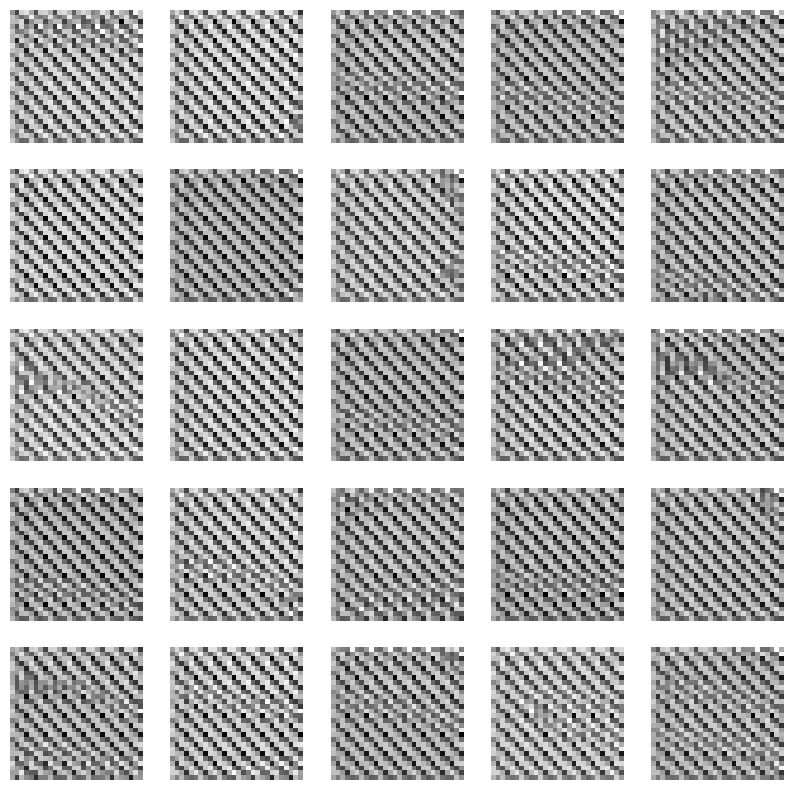

In [ ]:
# Use the trained model to generate images
predict(model)

In [ ]:
# Prediction function with step-by-step visualization
def predict_step(model, timesteps=50, num_samples=8):
    xs = []
    x = np.random.normal(size=(num_samples, 28, 28, 1))  # Adjusted for Fashion MNIST

    for i in trange(timesteps):
        t = np.full((num_samples, 1), i)  # Time as a column vector
        x = model.predict([x, t], verbose=0)
        if i % 5 == 0:  # Save every 5 steps to reduce the number of images
            xs.append(x[0])

    # Normalize images to the range [0, 1]
    xs = [(x - x.min()) / (x.max() - x.min()) for x in xs]

    plt.figure(figsize=(20, 3))
    for i, img in enumerate(xs):
        plt.subplot(1, len(xs), i + 1)
        plt.imshow(cvtImg(img), cmap='gray')
        plt.title(f'Step {i*5}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

100%|██████████| 50/50 [00:06<00:00,  7.42it/s]


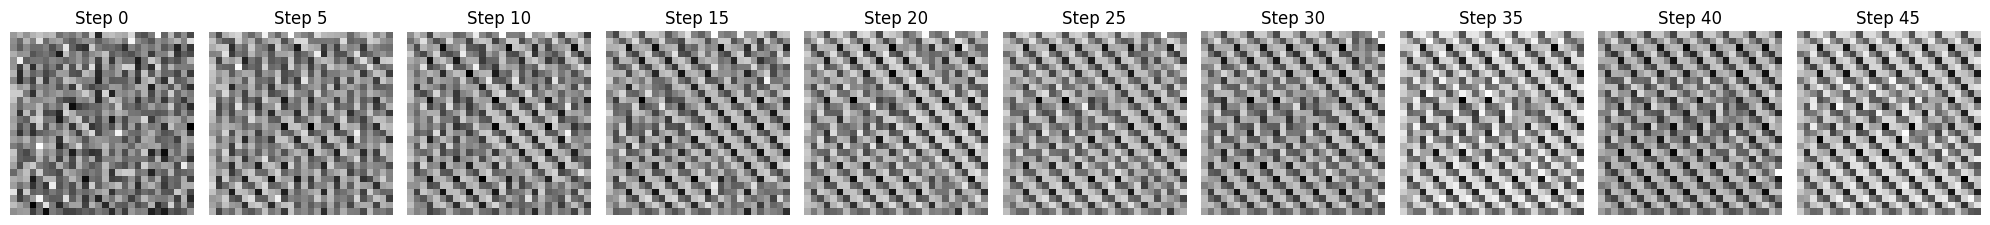

In [ ]:
# Run the step-by-step prediction
predict_step(model)

## 3.4. Training the U-Net

In [ ]:
# Training function for one batch
def train_one(x_img):
    x_ts = generate_ts(len(x_img))
    x_a, x_b = forward_noise(x_img, x_ts)
    loss = model.train_on_batch([x_a, x_ts], x_b)
    return loss

In [ ]:
# Training loop
def train(R=50):
    bar = trange(R)
    total = 100
    for i in bar:
        for j in range(total):
            x_img = X_train[np.random.randint(len(X_train), size=BATCH_SIZE)]
            loss = train_one(x_img)
            pg = (j / total) * 100
            if j % 5 == 0:
                bar.set_description(f'loss: {loss:.5f}, p: {pg:.2f}%')

  0%|          | 0/50 [00:00<?, ?it/s]2025-10-28 22:31:24.409058: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3319', 4 bytes spill stores, 4 bytes spill loads

2025-10-28 22:31:24.723240: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1357', 1268 bytes spill stores, 1192 bytes spill loads

100%|██████████| 50/50 [00:04<00:00, 12.27it/s]


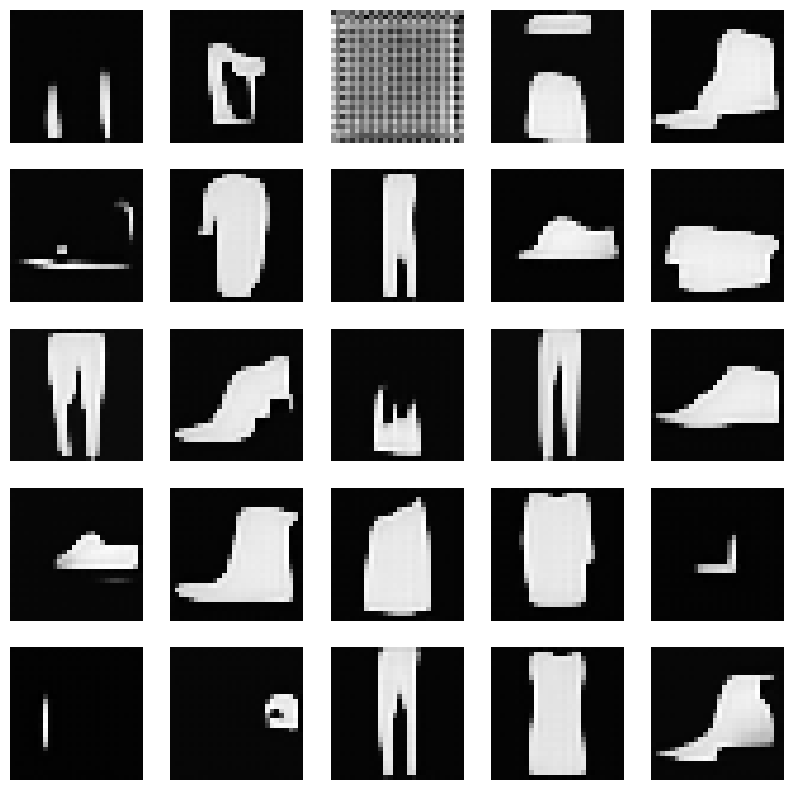

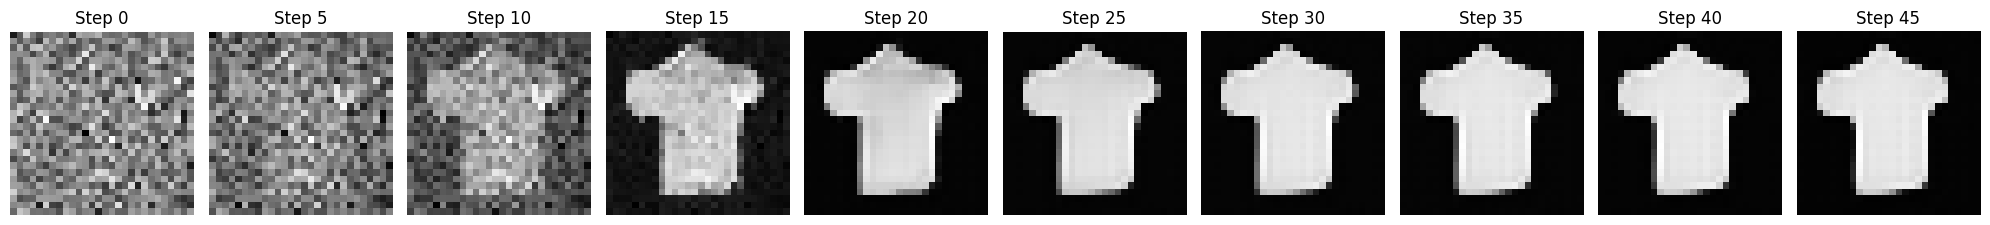

In [ ]:
# Start the training
train()
predict(model)
predict_step(model)

# 4. Using Stable Diffusion

## 4.1. Gerando com o Stable Diffusion

In [ ]:
import time
import keras_cv
from tensorflow import keras
import matplotlib.pyplot as plt
import tensorflow as tf

2025-10-28 22:56:14.324897: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-28 22:56:12.413234: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-28 22:56:15.113438: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/anderjcruz/Deep-Learning/venv/lib/python3.12/site-packages/tqdm/auto.py:21

In [ ]:
# Load the Stable Diffusion model
model = keras_cv.models.StableDiffusion(img_width=512, img_height=512)

imagens = model.text_to_image("Cat wearing blue jeans", batch_size=3)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


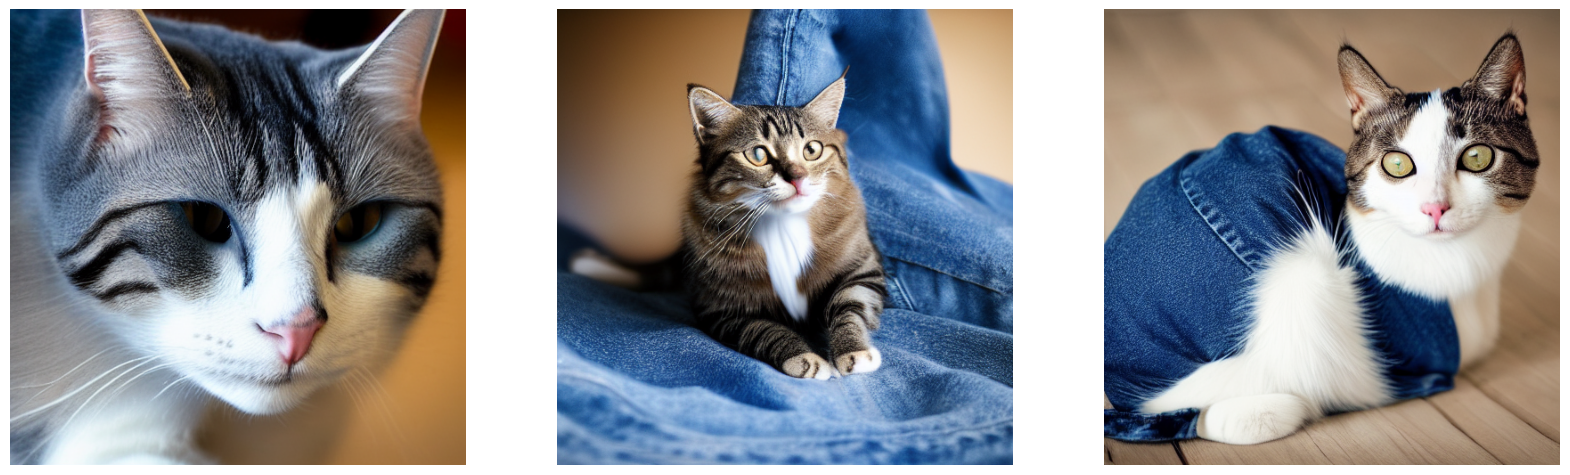

In [ ]:
# Function to plot images
def plot_images(imagens):
    plt.figure(figsize=(20, 20))
    for i in range(len(imagens)):
        ax = plt.subplot(1, len(imagens), i + 1)
        plt.imshow(imagens[i])
        plt.axis("off")

    plt.show()

## 4.2. Improving Accuracy

In [ ]:
# Generate images with a detailed prompt
imagens = model.text_to_image(
    "Humanoid cat wearing golden jeans, dark fantasy art, "
    "high quality, highly detailed, elegant, sharp focus, "
    "concept art, character concepts, digital painting, mystery, adventure",
    batch_size=3,
)

 2/50 [>.............................] - ETA: 37s

50/50 [==============================] - 39s 770ms/step


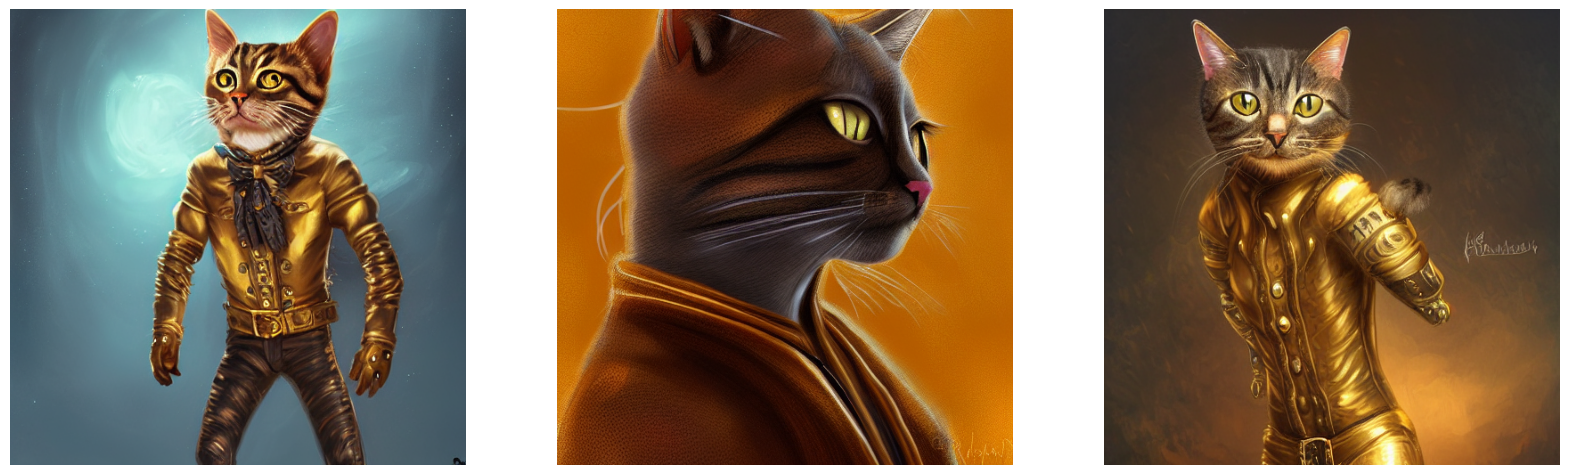

In [ ]:
# Plot the generated images
plot_images(imagens)

In [ ]:
# Enable mixed precision for faster inference
keras.mixed_precision.set_global_policy("mixed_float16")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA L4, compute capability 8.9


In [ ]:
# Load the Stable Diffusion model with mixed precision
model = keras_cv.models.StableDiffusion(img_width=512, img_height=512)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


In [ ]:
# Generate images with a detailed prompt
imagens = model.text_to_image(
    "Panda wearing a blue hat, dark fantasy art, "
    "high quality, highly detailed, elegant, sharp focus, "
    "concept art, character concepts, digital painting, mystery, adventure",
    batch_size=3,
)

50/50 [==============================] - 19s 386ms/step


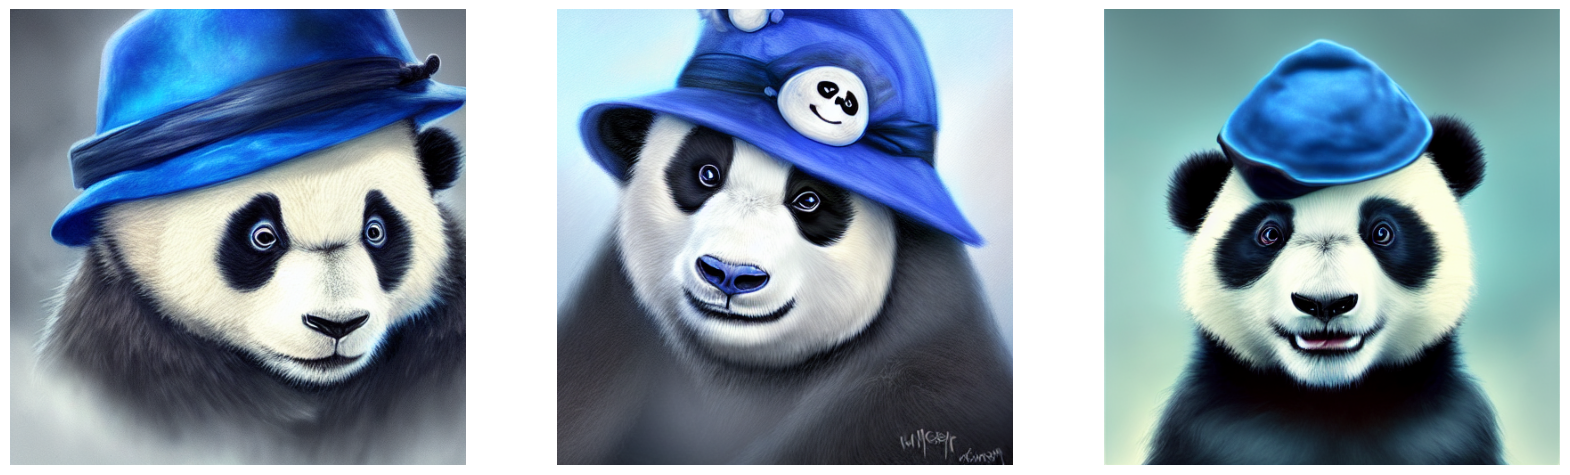

In [ ]:
# Plot the generated images
plot_images(imagens)

In [ ]:
# Disable mixed precision for standard inference
keras.mixed_precision.set_global_policy("float32")
model = keras_cv.models.StableDiffusion(img_width=512, img_height=512,jit_compile=True)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


In [ ]:
# Generate images with a detailed prompt
imagens = model.text_to_image(
    "Cat wearing a furry hat, dark fantasy art, "
    "high quality, highly detailed, elegant, sharp focus, "
    "concept art, character concepts, digital painting, mystery, adventure",
    batch_size=3,
)

50/50 [==============================] - 39s 773ms/step


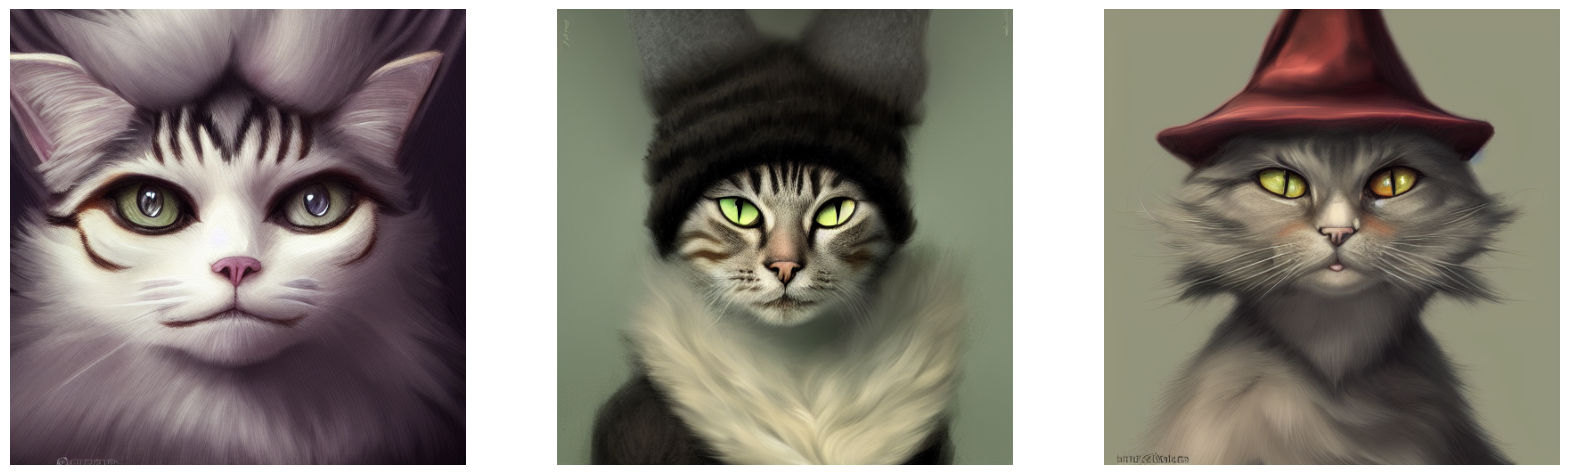

In [ ]:
# Plot the generated images
plot_images(imagens)

# 5. Generating Animations with Stable Diffusion

In [ ]:
import keras_cv
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
import numpy as np
import math
from PIL import Image
import tensorflow as tf
import math
from IPython.display import Image as IImage

2024-09-20 11:36:22.743081: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-20 11:36:22.933870: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-20 11:36:22.934017: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-20 11:36:22.965644: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-20 11:36:23.057838: I tensorflow/core/platform/cpu_feature_guar

Using TensorFlow backend


In [ ]:
# Enable mixed precision for faster inference
keras.mixed_precision.set_global_policy("mixed_float16")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA L4, compute capability 8.9


In [ ]:
# Instantiate the Stable Diffusion model
model = keras_cv.models.StableDiffusion(jit_compile=True)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


In [ ]:
# Define two prompts for interpolation
prompt_1 = "Panda wearing a blue hat, dark fantasy art, "
prompt_2 = "Cat wearing a blue hat, dark fantasy art, "
interpolation_steps = 5

encoding_1 = tf.squeeze(model.encode_text(prompt_1))
encoding_2 = tf.squeeze(model.encode_text(prompt_2))

interpolated_encodings = tf.linspace(encoding_1, encoding_2, interpolation_steps)

# Show the size of the latent manifold
print(f"Encoding shape: {encoding_1.shape}")

2024-09-11 17:43:55.099782: I external/local_xla/xla/service/service.cc:168] XLA service 0xe59a300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-09-11 17:43:55.099833: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A10G, Compute Capability 8.6
2024-09-11 17:43:55.256047: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-09-11 17:43:55.702905: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2024-09-11 17:43:56.840570: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_464', 12 bytes spill stores, 12 bytes spill loads

2024-09-11 17:43:57.742368: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local 

Encoding shape: (77, 768)


In [ ]:
seed = 12345
noise = tf.random.normal((512 // 8, 512 // 8, 4), seed=seed)

images = model.generate_image(
    interpolated_encodings,
    batch_size=interpolation_steps,
    diffusion_noise=noise,
)

In [ ]:
def export_as_gif(filename, images, frames_per_second=10, rubber_band=False):
    if rubber_band:
        images += images[2:-1][::-1]
    images[0].save(
        filename,
        save_all=True,
        append_images=images[1:],
        duration=1000 // frames_per_second,
        loop=0,
    )

In [ ]:
export_as_gif(
    "panda-cat.gif",
    [Image.fromarray(img) for img in images],
    frames_per_second=2,
    rubber_band=True,
)

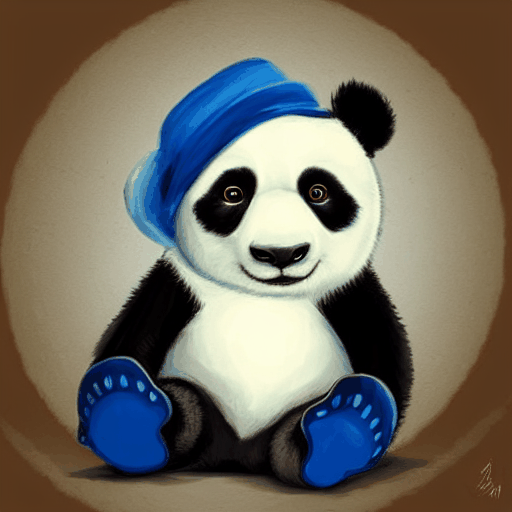

In [ ]:
IImage("panda-cat.gif")

## 5.2. Manual Interpolation of Results

In [ ]:
interpolation_steps = 150
batch_size = 3
batches = interpolation_steps // batch_size

interpolated_encodings = tf.linspace(encoding_1, encoding_2, interpolation_steps)
batched_encodings = tf.split(interpolated_encodings, batches)

images = []
for batch in range(batches):
    images += [
        Image.fromarray(img)
        for img in model.generate_image(
            batched_encodings[batch],
            batch_size=batch_size,
            num_steps=25,
            diffusion_noise=noise,
        )
    ]

export_as_gif("panda-cat-fino.gif", images, rubber_band=True)

2024-09-11 13:59:52.968357: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_3174', 176 bytes spill stores, 176 bytes spill loads

2024-09-11 13:59:53.050479: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1101', 4 bytes spill stores, 4 bytes spill loads

2024-09-11 13:59:53.576994: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_8250', 4 bytes spill stores, 4 bytes spill loads

2024-09-11 13:59:53.676907: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:326] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_3168', 8 bytes spill stores, 8 bytes spill loads

2024-09-11 13:59:54.018424: I external/local_xla/xla/stream_executor/gpu/asm_compiler.cc

25/25 [==============================] - 7s 267ms/step


## 5.3. Creating a Circular Path with Noise

In [ ]:
# Set seed to ensure consistent noise
seed = 42
tf.random.set_seed(seed)

# Fix prompt and encoding
prompt = "A majestic cat wearing an ornate golden hat, surrounded by floating orbs of light, in a dark illuminist painting, high detail, cinematic lighting, surreal background, elegant fur texture"
encoding = tf.squeeze(model.encode_text(prompt))  # Encoding will always be the same

# Circular walk parameters
walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size

# Generate noise with fixed seed
noise = tf.random.normal((512 // 8, 512 // 8, 4), seed=seed)  # Initial fixed noise

# Generate circular noises with the same seed
walk_noise_x = tf.random.normal(noise.shape, dtype="float64", seed=seed)
walk_noise_y = tf.random.normal(noise.shape, dtype="float64", seed=seed)

# Circular walk using cosine and sine
walk_scale_x = tf.cos(tf.linspace(0, 4, walk_steps) * math.pi)
walk_scale_y = tf.sin(tf.linspace(0, 4, walk_steps) * math.pi)

# Apply circular noise
noise_x = tf.tensordot(walk_scale_x, walk_noise_x, axes=0)
noise_y = tf.tensordot(walk_scale_y, walk_noise_y, axes=0)
noise = tf.add(noise_x, noise_y)

# Split noise into batches
batched_noise = tf.split(noise, batches)

# Generate images using manually created noise
images = []
for batch in range(batches):
    images += [
        Image.fromarray(img)
        for img in model.generate_image(
            encoding,
            batch_size=batch_size,
            num_steps=25,
            diffusion_noise=batched_noise[batch],  # Using only the generated noise
        )
    ]

# Export as GIF with a "back-and-forth" effect
export_as_gif("cat_hat_variation.gif", images, rubber_band=True)

25/25 [==============================] - 10s 388ms/step
